# Create WecOptTool Model for the Marson WEC concept

In [17]:
import numpy as np
import jax.numpy as jnp
import capytaine as cpt
from capytaine.io.meshio import load_from_meshio
import matplotlib.pyplot as plt
from scipy.optimize import brute
import pygmsh
import gmsh
from scipy.linalg import block_diag
import xarray as xr
import jax
import os

import wecopttool as wot

## set colorblind-friendly colormap for plots
plt.style.use('tableau-colorblind10')

import logging
logging.getLogger().setLevel(logging.INFO)

### Waves and Frequency array

In [18]:
wavefreq = 1/8 # Hz
f1 = wavefreq
nfreq = 10

freq = wot.frequency(f1, nfreq, False) # False -> no zero frequency

amplitude = 0.01/2 # m
phase = 30 # degrees
wavedir = 0 # degrees

waves = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

#### WEC geometry mesh
Now we will create a surface mesh for the WEC hull and store it using the `FloatingBody` object from Capytaine.

INFO:capytaine.io.meshio:Stored 3980 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_24"), lid_mesh=None, dofs={}, center_of_mass=[ 0.    0.   -0.54], name="platform").
INFO:capytaine.bodies.bodies:Clipping platform with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").rotation_center = [ 0.    0.   -0.54]
INFO:capytaine.io.meshio:Stored 312 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_30"), lid_mesh=None, dofs={}, center_of_mass=[-0.72  0.   -0.36], name="flap1").
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap1").rotation_center = [-0.72, 0, -0.36]
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(nor

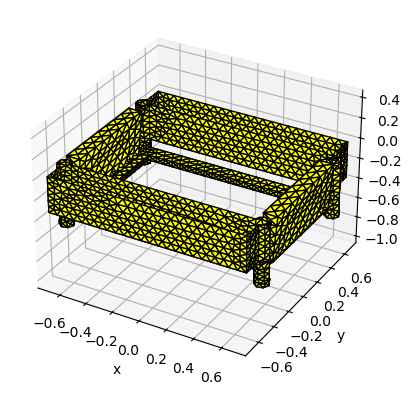

In [19]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop = 0.1

platformLength = 1.44 
outboardWidth = 0.1
platformWidth = 0.76+2*outboardWidth
platformHeight = 0.05
platformCenter = [0, 0, -0.46]
columnsRadius = 0.05
columnsDraft = 0.6
columnsXY = [platformLength/2, platformWidth/2]
cutoutWidth = 0.76
cutoutLength = 1.44-2*outboardWidth

# floats attached to side of platform
floatWidth = 0.2
floatHeight = 0.35

flapWidth = platformWidth-2*outboardWidth
flapHeight = 0.45
flap1CG = [-platformLength/2, 0, -0.36] # from water surface/origin
flap2CG = [platformLength/2, 0, -0.36] # from water surface/origin

with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', 0.3)
    platform = geom.add_box([-platformLength/2, -platformWidth/2, platformCenter[2] - platformHeight/2], [platformLength,platformWidth,platformHeight])
    cutout = geom.add_box([-cutoutLength/2, -cutoutWidth/2, platformCenter[2] - platformHeight/2], [cutoutLength,cutoutWidth,platformHeight])
    cyl1 = geom.add_cylinder([-columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl2 = geom.add_cylinder([-columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl3 = geom.add_cylinder([columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl4 = geom.add_cylinder([columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    float1 = geom.add_box([-platformLength/2, -platformWidth/2-0.2, -floatHeight], [platformLength,floatWidth,floatHeight])
    float2 = geom.add_box([-platformLength/2, platformWidth/2, -floatHeight], [platformLength,floatWidth,floatHeight])
    platformCutout = geom.boolean_difference(platform,cutout)
    geom.boolean_union([platformCutout,cyl1,cyl2,cyl3,cyl4,float1,float2])
    platformMesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
            [[-platformLength/2 - flapThicknessBottom/2, -flapWidth/2, platformCenter[2]],
            [-platformLength/2 + flapThicknessBottom/2, -flapWidth/2, platformCenter[2]],
            [-platformLength/2 + flapThicknessTop/2, -flapWidth/2, -.01],
            [-platformLength/2 - flapThicknessTop/2, -flapWidth/2, -.01]],mesh_size=0.1)
    geom.extrude(flap1,[0,flapWidth,0])
    flap1Mesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap2 = geom.add_polygon(
            [[platformLength/2 - flapThicknessBottom/2, -flapWidth/2, platformCenter[2]],
            [platformLength/2 + flapThicknessBottom/2, -flapWidth/2, platformCenter[2]],
            [platformLength/2 + flapThicknessTop/2, -flapWidth/2, -.01],
            [platformLength/2 - flapThicknessTop/2, -flapWidth/2, -.01]],mesh_size=0.1)
    geom.extrude(flap2,[0,flapWidth,0])
    flap2Mesh = geom.generate_mesh()


# define the floating body
platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform', center_of_mass=[0,0,-0.54])
platform = platform.immersed_part()
platform.rotation_center = platform.center_of_mass
platform.add_translation_dof(name='Surge')
platform.add_translation_dof(name='Heave')
platform.add_rotation_dof(name='Pitch')
platform.inertia_matrix = platform.compute_rigid_body_inertia()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([350,350,30]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(platform.dofs),
                                    'radiating_dof': list(platform.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
platform.inertia_matrix = rigid_inertia_matrix_xr
platform.hydrostatic_stiffness = platform.compute_hydrostatic_stiffness(rho=1025)

# define the floating body
flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)
flap1.rotation_center = flap1CG # define rotation about cg and M4E will handle transformaiton
flap1.add_translation_dof(name='Surge')
flap1.add_translation_dof(name='Heave')
flap1.add_rotation_dof(name='Pitch')
#flap1.mass = 0.2*1000*flapWidth*flapThickness*flapHeight
#flap1.inertia_matrix = flap1.compute_rigid_body_inertia()
flap1 = flap1.immersed_part()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([0.5*(.05*.76*.56)*1000,0.5*(.05*.76*.56)*1000,1.19]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap1.dofs),
                                    'radiating_dof': list(flap1.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap1.inertia_matrix = rigid_inertia_matrix_xr
flap1.hydrostatic_stiffness = flap1.compute_hydrostatic_stiffness(rho=1025)

# define the floating body
flap2 = cpt.FloatingBody(mesh=flap2Mesh, name=f'flap2', center_of_mass=flap2CG)
flap2.rotation_center = flap2CG
flap2.add_translation_dof(name='Surge')
flap2.add_translation_dof(name='Heave')
flap2.add_rotation_dof(name='Pitch')
#flap2.mass = 0.2*1000*flapWidth*flapThickness*flapHeight
#flap2.inertia_matrix = flap2.compute_rigid_body_inertia()
flap2 = flap2.immersed_part()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([0.5*(.05*.76*.56)*1000,0.5*(.05*.76*.56)*1000,1.19]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap2.dofs),
                                    'radiating_dof': list(flap2.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap2.inertia_matrix = rigid_inertia_matrix_xr
flap2.hydrostatic_stiffness = flap2.compute_hydrostatic_stiffness(rho=1025)

all_bodies = flap1 + flap2 + platform

#all_bodies.show()
all_bodies.show_matplotlib()

In [21]:
fname = 'bem.nc'
if os.path.exists(fname):
    bem_data = wot.read_netcdf(fname)
else:
    bem_data = wot.run_bem(all_bodies, freq, wave_dirs=0)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(fname, bem_data)

Problem initialization finished in:		 0.002 seconds
All branches in the graph:
Branch 1: [1, 2]
Branch 2: [1, 3]


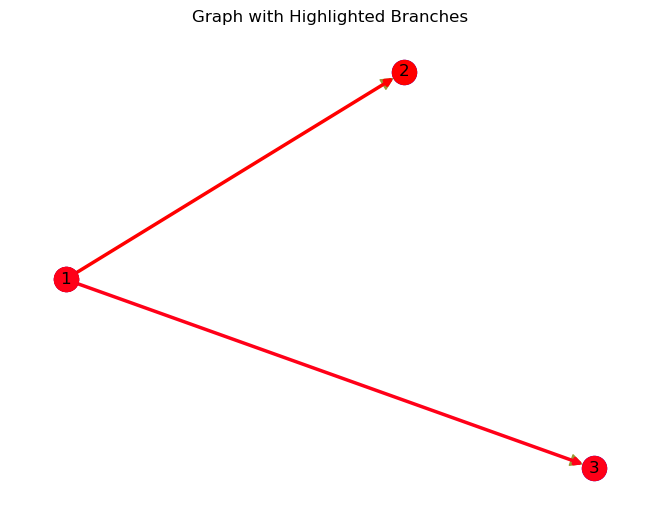

R and RD matrices calculation finished in:	 0.255 seconds
Symbolic EOM computation finished in:		 0.012 seconds
Compiling EOM expressions finished in:		 0.310 seconds
Original Rotation Matrix (R):
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [1.00000000000000 0 0.72*sin(Theta_1) + 0.04*cos(Theta_1)
  0.14*cos(Theta_2) 0]
 [0 1.00000000000000 -0.04*sin(Theta_1) + 0.72*cos(Theta_1)
  -0.14*sin(Theta_2) 0]
 [0 0 0 1 0]
 [1.00000000000000 0 -0.72*sin(Theta_1) + 0.04*cos(Theta_1) 0
  0.14*cos(Theta_3)]
 [0 1.00000000000000 -0.04*sin(Theta_1) - 0.72*cos(Theta_1) 0
  -0.14*sin(Theta_3)]
 [0 0 0 0 1]]
Substituted Rotation Matrix (R_subs):
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [1.00000000000000 0 0.0400000000000000 0.140000000000000 0]
 [0 1.00000000000000 0.720000000000000 0 0]
 [0 0 0 1 0]
 [1.00000000000000 0 0.0400000000000000 0 0.140000000000000]
 [0 1.00000000000000 -0.720000000000000 0 0]
 [0 0 0 0 1]]


In [22]:
import multibody as mb
import sympy
import m4e_foswec

MBDsys = mb.MBDSystem.from_example(m4e_foswec)

# Print the original rotation matrix
print("Original Rotation Matrix (R):")
print(np.array(MBDsys.R))

# Create a mapping of symbols to values based on their names
value_mapping = {
    'Theta_1': 0,
    'Theta_2': 0,
    'Theta_3': 0,
}

substitution_dict = {symbol: value_mapping[str(symbol)] for symbol in list(MBDsys.R.free_symbols) if str(symbol) in value_mapping}
R_subs = MBDsys.R.subs(substitution_dict)
print("Substituted Rotation Matrix (R_subs):")
print(np.array(R_subs))


In [23]:
# Verify that mass matrix is equivalent using MBCsys and R
# Print the original rotation matrix
#print("Original Mass Matrix (ReducedM):")
#print(np.array(MBDsys.ReducedM))

# Create a mapping of symbols to values based on their names
value_mapping = {
    'm1': platform.inertia_matrix[0,0].values,
    'm2': flap1.inertia_matrix[0,0].values,
    'm3': flap2.inertia_matrix[0,0].values,
    'J1': platform.inertia_matrix[2,2].values,
    'J2': flap1.inertia_matrix[2,2].values,
    'J3': flap2.inertia_matrix[2,2].values,
    'Theta_1': 0,
    'Theta_2': 0,
    'Theta_3': 0,
}

substitution_dict = {symbol: value_mapping[str(symbol)] for symbol in list(MBDsys.ReducedM.free_symbols) if str(symbol) in value_mapping}
ReducedM_subs = MBDsys.ReducedM.subs(substitution_dict)
#print("Substituted Mass Matrix (ReducedM_subs):")
#print(np.array(ReducedM_subs))

mass_matrix = block_diag(platform.inertia_matrix.values,flap1.inertia_matrix.values,flap2.inertia_matrix.values)

reduced_mass_matrix = np.array(R_subs,dtype=np.complex128).T @ mass_matrix @ np.array(R_subs,dtype=np.complex128)

#print("Check Mass Matrix (ReducedM_subs):")
#print(reduced_mass_matrix) # Matches!!

In [24]:
print(MBDsys.R)
print(np.array(R_subs))
print(np.array(R_subs).T)

Matrix([[1, 0, 0, 0, 0], [0, 1, 0, 0, 0], [0, 0, 1, 0, 0], [1.00000000000000, 0, 0.72*sin(Theta_1) + 0.04*cos(Theta_1), 0.14*cos(Theta_2), 0], [0, 1.00000000000000, -0.04*sin(Theta_1) + 0.72*cos(Theta_1), -0.14*sin(Theta_2), 0], [0, 0, 0, 1, 0], [1.00000000000000, 0, -0.72*sin(Theta_1) + 0.04*cos(Theta_1), 0, 0.14*cos(Theta_3)], [0, 1.00000000000000, -0.04*sin(Theta_1) - 0.72*cos(Theta_1), 0, -0.14*sin(Theta_3)], [0, 0, 0, 0, 1]])
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [1.00000000000000 0 0.0400000000000000 0.140000000000000 0]
 [0 1.00000000000000 0.720000000000000 0 0]
 [0 0 0 1 0]
 [1.00000000000000 0 0.0400000000000000 0 0.140000000000000]
 [0 1.00000000000000 -0.720000000000000 0 0]
 [0 0 0 0 1]]
[[1 0 0 1.00000000000000 0 0 1.00000000000000 0 0]
 [0 1 0 0 1.00000000000000 0 0 1.00000000000000 0]
 [0 0 1 0.0400000000000000 0.720000000000000 0 0.0400000000000000
  -0.720000000000000 0]
 [0 0 0 0.140000000000000 0 1 0 0 0]
 [0 0 0 0 0 0 0.140000000000000 0 1]]


In [25]:
added_mass = np.squeeze(bem_data['added_mass'].data) # Added mass
radiation_damping = np.squeeze(bem_data['radiation_damping'].data)  # Radiation damping
hydrostatic_stiffness = np.squeeze(bem_data['hydrostatic_stiffness'].data)  # Hydrostatic stiffness
excitation_force = np.squeeze(bem_data['excitation_force'].data) # Excitation force

omega = freq*2*np.pi
impedance_matrix = (mass_matrix + added_mass)*1j*omega[:, np.newaxis, np.newaxis] + radiation_damping - (1j/omega[:, np.newaxis, np.newaxis])*np.repeat(hydrostatic_stiffness[np.newaxis, :, :], 10, axis=0)
impedance_reduced = np.array(R_subs,dtype=np.complex128).T @ impedance_matrix @ np.array(R_subs,dtype=np.complex128)
print(np.shape(impedance_reduced))

hydrostatic_stiffness_reduced = (np.array(R_subs,dtype=np.complex128).T @ hydrostatic_stiffness @ np.array(R_subs,dtype=np.complex128))
print(np.shape(hydrostatic_stiffness_reduced))

excitation_reduced = np.squeeze(bem_data['excitation_force'].values @ np.array(R_subs,dtype=np.complex128))[:,np.newaxis,:]

wave_direction = np.array([wavedir,])
nwave_direction = len(wave_direction)
coords_exc = {
    'omega': (['omega'], omega, {'units': 'rad/s'}),
    'wave_direction': (['wave_direction'], wave_direction, {'units': 'rad'}),
    'influenced_dof': (['influenced_dof'], ['surge_platform', 'heave_platform','pitch_platform','pitch_flap1','pitch_flap2'], {}),
}
excitation_reduced = xr.DataArray(excitation_reduced, coords=coords_exc, attrs={})

print(np.shape(excitation_reduced))

(10, 5, 5)
(5, 5)
(10, 1, 5)


In [26]:
# add forces to stabilize system

mooring_stiffness = np.diag([3*1e5, 6e4, 5e4, 0, 0, 0, 0, 0, 0])
mooring_stiffness = np.array(R_subs,dtype=np.float64).T @ mooring_stiffness @ np.array(R_subs,dtype=np.float64)

mooring_damping = np.diag([3*1e4, 5e4, 5e5, 0, 0, 0, 0, 0, 0])
mooring_damping = np.array(R_subs,dtype=np.float64).T @ mooring_damping @ np.array(R_subs,dtype=np.float64)

print(mooring_stiffness)
print(mooring_damping)

def f_mooring(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
 
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    mooring = -pos @ mooring_stiffness - vel @ mooring_damping
    mooring_force = jnp.dot(time_matrix,mooring)
    #print(mooring_force)
    return mooring_force

# add prentension 
def f_pretension(wec, x_wec, x_opt, wave, nsubsteps=1):
    pretension = np.zeros((20,5))
    pretension[:,1] = -9.81*2*(1-0.5)*(flapThicknessBottom*platformWidth*-platformCenter[2])*1000
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    pretension_force = jnp.dot(time_matrix,pretension)
    return pretension_force
# WecOptTool does not take gravity into account and assumes equilibrium so no pretension needed?

f_add = {'mooring': f_mooring}

[[300000.      0.      0.      0.      0.]
 [     0.  60000.      0.      0.      0.]
 [     0.      0.  50000.      0.      0.]
 [     0.      0.      0.      0.      0.]
 [     0.      0.      0.      0.      0.]]
[[ 30000.      0.      0.      0.      0.]
 [     0.  50000.      0.      0.      0.]
 [     0.      0. 500000.      0.      0.]
 [     0.      0.      0.      0.      0.]
 [     0.      0.      0.      0.      0.]]


In [27]:
wec = wot.WEC.from_impedance(
    freq,
    impedance=impedance_reduced,
    exc_coeff=excitation_reduced,
    hydrostatic_stiffness=hydrostatic_stiffness_reduced,
    constraints=None,
    f_add=f_add,
)

# Objective function
obj_fun = lambda wec, x_wec, x_opt, waves : 0
nstate_opt = 0

# Solve
scale_x_wec = 1e1
scale_x_opt = 1e-3
scale_obj = 1e-2

results = wec.solve(
    waves,
    obj_fun,
    nstate_opt,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
)


INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [5.57e-02, nan, 0.00e+00]
INFO:wecopttool.core:Optimization terminated successfully    (Exit mode 0)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1


c:\Users\jtgrasb\AppData\Local\anaconda3\envs\wot_dev\Lib\site-packages\wecopttool\core.py:967: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'omega' ('omega',) The recommendation is to set join explicitly for this case.
  results_fd = xr.merge([fd_state, fd_forces, wave])
c:\Users\jtgrasb\AppData\Local\anaconda3\envs\wot_dev\Lib\site-packages\wecopttool\core.py:967: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  results_fd 

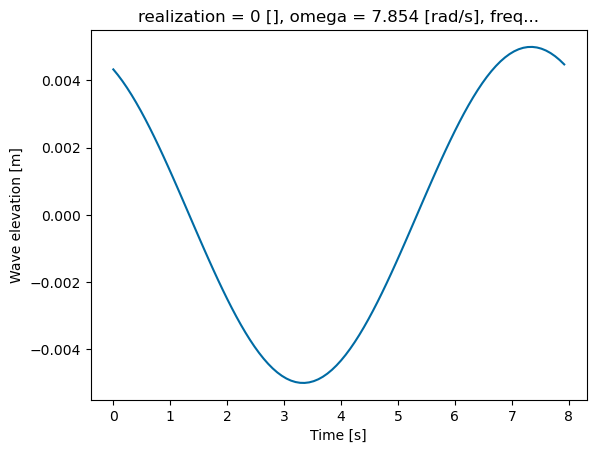

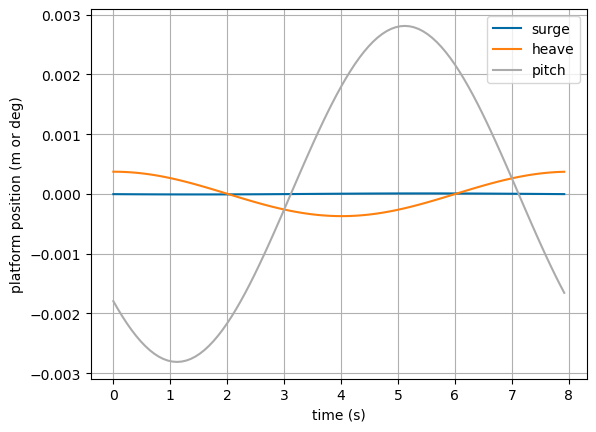

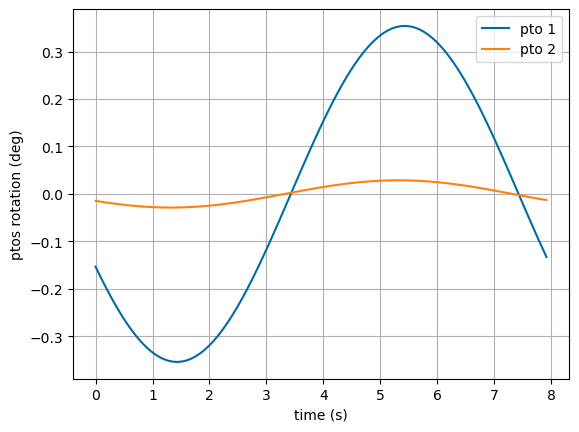

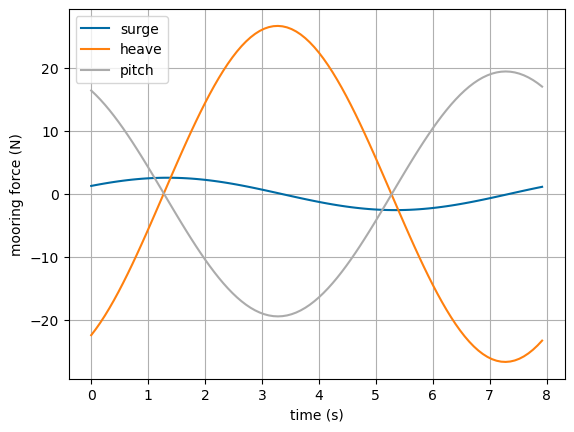

In [28]:
nsubsteps = 5
wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)

wec_tdom['wave_elev'].plot()

plt.figure()
plt.plot(wec_tdom['time'],wec_tdom.pos[0,0,:])
plt.plot(wec_tdom['time'],wec_tdom.pos[0,1,:])
plt.plot(wec_tdom['time'],wec_tdom.pos[0,2,:]*180/np.pi)
plt.xlabel('time (s)')
plt.ylabel('platform position (m or deg)')
plt.legend(['surge','heave','pitch'])
plt.grid()


plt.figure()
plt.plot(wec_tdom['time'],wec_tdom.pos[0,3,:]*180/np.pi)
plt.plot(wec_tdom['time'],wec_tdom.pos[0,4,:]*180/np.pi)
plt.xlabel('time (s)')
plt.ylabel('ptos rotation (deg)')
plt.legend(['pto 1', 'pto 2'])
plt.grid()

#print(wec_tdom['force'].sel(type='mooring').coords)

plt.figure()
plt.plot(wec_tdom['time'],np.squeeze(wec_tdom['force'].sel(type='mooring',influenced_dof='DOF_0')))
plt.plot(wec_tdom['time'],np.squeeze(wec_tdom['force'].sel(type='mooring',influenced_dof='DOF_1')))
plt.plot(wec_tdom['time'],np.squeeze(wec_tdom['force'].sel(type='mooring',influenced_dof='DOF_2')))
plt.xlabel('time (s)')
plt.ylabel('mooring force (N)')
plt.legend(['surge', 'heave','pitch'])
plt.grid()